### **WP3.2 - logistic regression baseline**

This notebook trains interpretable logistic regression baselines using the selected WP3.1 processed matrix.


##### **Notebook Outline**

- **matrix load:** load processed predictors, labels, identifiers, and class-imbalance summaries from WP3.1.
- **reference models:** train baseline and class-weighted logistic regression comparators.
- **regularisation tuning:** screen logistic settings using validation PR-AUC and evaluate threshold behaviour.
- **output save:** save predictions, coefficients, threshold tables, calibration outputs, and workbook summaries.


In [ ]:
#import core libraries used for modelling, evaluation, saving outputs, and plotting
import sys
import os
from pathlib import Path
import warnings
import time
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier as ReferenceBaselineClassifier
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve)
print(sys.executable)

mkdir -p failed for path /private/tmp/mplconfig: [Errno 13] Permission denied: '/private'
Matplotlib created a temporary cache directory at /tmp/matplotlib-pyir6on1 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


/scratch/DissProject/my_env/bin/python


**Import libraries and define paths**

The notebook loads the processed modelling artefacts from WP3.1 and saves all T3.2 outputs into a dedicated folder.

In [ ]:
#define project paths and create a dedicated output folder for wp3.2 artefacts
warnings.filterwarnings("ignore")

current_path = Path.cwd().resolve()
project_path = None
for candidate_path in [current_path] + list(current_path.parents):
    if (candidate_path / "code").exists():
        project_path = candidate_path
        break
if project_path is None:
    project_path = Path("/Users/ahthini/Desktop/DissProject")
wp3_input_variant = "shap_guided_reduced_feature_set"
wp3_1_output_path = project_path / "outputs" / "WP3_1"
wp3_2_output_path = project_path / "outputs" / "WP3_2"
wp3_2_output_path.mkdir(exist_ok=True)

#use the shap-guided reduced wp3.1 processed matrices and previously selected model settings
run_hyperparameter_screening = True

#organise outputs by model
reference_baseline_output_path = wp3_2_output_path / "reference_baseline"
logistic_output_path = wp3_2_output_path / "logistic_regression"
tuned_logistic_output_path = wp3_2_output_path / "tuned_logistic_regression"
reference_baseline_output_path.mkdir(exist_ok=True)
logistic_output_path.mkdir(exist_ok=True)
tuned_logistic_output_path.mkdir(exist_ok=True)

print(sys.executable)
print("WP3 input variant:", wp3_input_variant)
print("WP3.1 input folder:", wp3_1_output_path)
print("WP3.2 output folder:", wp3_2_output_path)
print("Reference baseline output folder:", reference_baseline_output_path)
print("Logistic regression output folder:", logistic_output_path)
print("Tuned logistic regression output folder:", tuned_logistic_output_path)

/scratch/DissProject/my_env/bin/python
WP3 input variant: shap_guided_reduced_feature_set
WP3.1 input folder: /scratch/DissProject/outputs/WP3_1
WP3.2 output folder: /scratch/DissProject/outputs/WP3_2
Reference baseline output folder: /scratch/DissProject/outputs/WP3_2/reference_baseline
Logistic regression output folder: /scratch/DissProject/outputs/WP3_2/logistic_regression
Tuned logistic regression output folder: /scratch/DissProject/outputs/WP3_2/tuned_logistic_regression


**Load WP3.1 modelling matrices**

The processed matrices already include imputation, numerical standardisation, and categorical one-hot encoding fitted on the training set only.

In [ ]:
#load processed matrices, labels, identifiers, and feature names created in wp3.1
#wp3_input_variant controls the processed feature matrix used as the primary modelling input.
#use "full" for the complete processed matrix, "clean_feature_audit" for leakage-cleaned features,
#"runtime_trimmed_feature_audit" for the audit-trimmed matrix, or "shap_guided_reduced_feature_set" for the primary small primary matrix.
if wp3_input_variant in ["full", "original", "complete"]:
    X_train_file = wp3_1_output_path / "t3_1_X_train_processed.npz"
    X_test_file = wp3_1_output_path / "t3_1_X_test_processed.npz"
    feature_names_file = wp3_1_output_path / "t3_1_processed_feature_names.csv"
else:
    matrix_suffix = f"_{wp3_input_variant}"
    X_train_file = wp3_1_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
    X_test_file = wp3_1_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
    feature_names_file = wp3_1_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

#backward-compatible fallback for reduced matrices created by the embedded wp3.1 feature-audit extension
if not X_train_file.exists() or not X_test_file.exists() or not feature_names_file.exists():
    wp3_feature_audit_output_path = project_path / "outputs" / "WP3_feature_audit"
    if wp3_input_variant not in ["full", "original", "complete"]:
        X_train_file = wp3_feature_audit_output_path / f"t3_1_X_train_processed{matrix_suffix}.npz"
        X_test_file = wp3_feature_audit_output_path / f"t3_1_X_test_processed{matrix_suffix}.npz"
        feature_names_file = wp3_feature_audit_output_path / f"t3_1_processed_feature_names{matrix_suffix}.csv"

missing_input_files = [path for path in [X_train_file, X_test_file, feature_names_file] if not path.exists()]
if missing_input_files:
    raise FileNotFoundError("Missing WP3 input files: " + ", ".join(str(path) for path in missing_input_files))

X_train = sparse.load_npz(X_train_file)
X_test = sparse.load_npz(X_test_file)
y_train = pd.read_csv(wp3_1_output_path / "t3_1_y_train.csv")["readmitted_30d"].astype(int)
y_test = pd.read_csv(wp3_1_output_path / "t3_1_y_test.csv")["readmitted_30d"].astype(int)
train_ids = pd.read_csv(wp3_1_output_path / "t3_1_train_ids.csv")
test_ids = pd.read_csv(wp3_1_output_path / "t3_1_test_ids.csv")
feature_names = pd.read_csv(feature_names_file)["processed_feature_name"].tolist()
class_weight_summary = pd.read_csv(wp3_1_output_path / "t3_1_class_weight_summary.csv")

print("WP3 input variant:", wp3_input_variant)
print("Training matrix file:", X_train_file)
print("Test matrix file:", X_test_file)
print("Feature names file:", feature_names_file)
print("Training matrix shape:", X_train.shape)
print("Test matrix shape:", X_test.shape)
print("Number of processed feature names:", len(feature_names))
print()
print("Training outcome distribution:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))
print()
print("Test outcome distribution:")
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))
print()
print("Class imbalance summary from WP3.1:")
print(class_weight_summary)

WP3 input variant: shap_guided_reduced_feature_set
Training matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_train_processed_shap_guided_reduced_feature_set.npz
Test matrix file: /scratch/DissProject/outputs/WP3_1/t3_1_X_test_processed_shap_guided_reduced_feature_set.npz
Feature names file: /scratch/DissProject/outputs/WP3_1/t3_1_processed_feature_names_shap_guided_reduced_feature_set.csv
Training matrix shape: (191320, 973)
Test matrix shape: (47171, 973)
Number of processed feature names: 973

Training outcome distribution:
readmitted_30d
0    153281
1     38039
Name: count, dtype: int64
readmitted_30d
0    80.12
1    19.88
Name: proportion, dtype: float64

Test outcome distribution:
readmitted_30d
0    37852
1     9319
Name: count, dtype: int64
readmitted_30d
0    80.24
1    19.76
Name: proportion, dtype: float64

Class imbalance summary from WP3.1:
                    metric        value
0  training_negative_cases  153281.0000
1  training_positive_cases   38039.0000
2   posit

**Define reusable evaluation functions**

The same evaluation logic can be reused for Random Forest and XGBoost later, ensuring model comparisons are consistent.

In [ ]:
#define helper functions so  same evaluation logic can be reused in later model notebooks
def evaluate_binary_predictions(model_name, y_true, y_probability, threshold=0.5):
    #convert probabilities to binary predictions at the selected threshold
    y_pred = (y_probability >= threshold).astype(int)
    #extract confusion matrix counts for sensitivity and specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {"model": model_name, "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity, "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "pr_auc_average_precision": average_precision_score(y_true, y_probability),
        "brier_score": brier_score_loss(y_true, y_probability),
        "true_negatives": tn, "false_positives": fp, "false_negatives": fn, "true_positives": tp}

#find best threshold
def find_best_threshold(y_true, y_probability):
    #scan thresholds between 0.01 and 0.99 to avoid using test set for threshold selection
    thresholds = np.linspace(0.01, 0.99, 99)
    rows = []
    #loop through each item in this feature block
    for threshold in thresholds:
        y_pred = (y_probability >= threshold).astype(int)
        #extract confusion matrix counts for sensitivity and specificity
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
        specificity = tn / (tn + fp) if (tn + fp) else np.nan
        precision = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        rows.append({"threshold": threshold, "precision": precision, "recall_sensitivity": sensitivity,
            "precision_recall_gap": abs(precision - sensitivity), "f1_score": f1,
            "youden_index": sensitivity + specificity - 1, "sensitivity": sensitivity, "specificity": specificity})
        
    threshold_df = pd.DataFrame(rows)
    best_f1_threshold = threshold_df.sort_values("f1_score", ascending=False).iloc[0]["threshold"]
    best_youden_threshold = threshold_df.sort_values("youden_index", ascending=False).iloc[0]["threshold"]
    return threshold_df, float(best_f1_threshold), float(best_youden_threshold)

#save prediction file
def save_prediction_file(output_folder, file_name, ids, y_probability, threshold):
    pred_df = ids.copy()
    pred_df["predicted_probability"] = y_probability
    pred_df["predicted_class"] = (y_probability >= threshold).astype(int)
    #save this table or artefact for later review
    pred_df.to_csv(output_folder / file_name, index=False)
    return pred_df

#add timing metrics
def add_timing_metrics(metrics, training_time_seconds, train_inference_time_seconds, test_inference_time_seconds, number_of_test_admissions):
    #attach runtime values to a model performance dictionary for later comparison
    metrics = metrics.copy()
    metrics["training_time_seconds"] = training_time_seconds
    metrics["train_inference_time_seconds"] = train_inference_time_seconds
    metrics["test_inference_time_seconds"] = test_inference_time_seconds
    metrics["test_inference_time_per_admission_ms"] = (test_inference_time_seconds / number_of_test_admissions) * 1000
    return metrics

**Train a non-informative reference baseline model**

A reference classifier provides a minimum performance point. The logistic regression model should outperform this baseline on threshold-independent metrics such as ROC-AUC and PR-AUC.

In [ ]:
#fit reference baseline that predicts training-set class prevalence only
reference_baseline_model = ReferenceBaselineClassifier(strategy="prior", random_state=42)

reference_training_start = time.perf_counter()
reference_baseline_model.fit(X_train, y_train)
reference_training_time_seconds = time.perf_counter() - reference_training_start

reference_train_prediction_start = time.perf_counter()
reference_baseline_train_probability = reference_baseline_model.predict_proba(X_train)[:, 1]
reference_train_inference_time_seconds = time.perf_counter() - reference_train_prediction_start

reference_test_prediction_start = time.perf_counter()
reference_baseline_test_probability = reference_baseline_model.predict_proba(X_test)[:, 1]
reference_test_inference_time_seconds = time.perf_counter() - reference_test_prediction_start

reference_baseline_metrics = evaluate_binary_predictions("Reference baseline", y_test, reference_baseline_test_probability, threshold=0.5)
reference_baseline_metrics = add_timing_metrics(reference_baseline_metrics,
    reference_training_time_seconds, reference_train_inference_time_seconds,
    reference_test_inference_time_seconds, len(y_test))

print("Reference baseline test-set performance:")
print(pd.DataFrame([reference_baseline_metrics]).T)
print("\nReference baseline training time in seconds:", round(reference_training_time_seconds, 4))
print("Reference baseline test inference time in seconds:", round(reference_test_inference_time_seconds, 4))

Reference baseline test-set performance:
                                                       0
model                                 Reference baseline
threshold                                            0.5
accuracy                                        0.802442
balanced_accuracy                                    0.5
precision                                            0.0
recall_sensitivity                                   0.0
specificity                                          1.0
f1_score                                             0.0
roc_auc                                              0.5
pr_auc_average_precision                        0.197558
brier_score                                      0.15853
true_negatives                                     37852
false_positives                                        0
false_negatives                                     9319
true_positives                                         0
training_time_seconds                          

**Train class-weighted logistic regression**

Class weighting is used because approximately one in five admissions had the positive readmission outcome. Logistic regression is useful as an interpretable baseline and provides a benchmark for more flexible models.

In [ ]:
#fit main logistic regression baseline with balanced class weights for the imbalanced outcome
logistic_model = LogisticRegression(penalty="l2", C=1.0, solver="lbfgs",
    #class_weight="balanced" increases penalty for minority readmission class
    class_weight="balanced", max_iter=2000, random_state=42)

print("Training class-weighted logistic regression...")
logistic_training_start = time.perf_counter()
logistic_model.fit(X_train, y_train)
logistic_training_time_seconds = time.perf_counter() - logistic_training_start
print("Logistic regression training complete.")

logistic_train_prediction_start = time.perf_counter()
logistic_train_probability = logistic_model.predict_proba(X_train)[:, 1]
logistic_train_inference_time_seconds = time.perf_counter() - logistic_train_prediction_start

logistic_test_prediction_start = time.perf_counter()
logistic_test_probability = logistic_model.predict_proba(X_test)[:, 1]
logistic_test_inference_time_seconds = time.perf_counter() - logistic_test_prediction_start

print("Training ROC-AUC:", round(roc_auc_score(y_train, logistic_train_probability), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, logistic_test_probability), 4))
print("Training PR-AUC:", round(average_precision_score(y_train, logistic_train_probability), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, logistic_test_probability), 4))
print("Training time in seconds:", round(logistic_training_time_seconds, 2))
print("Test inference time in seconds:", round(logistic_test_inference_time_seconds, 4))
print("Test inference time per admission in ms:", round((logistic_test_inference_time_seconds / len(y_test)) * 1000, 6))

Training class-weighted logistic regression...
Logistic regression training complete.
Training ROC-AUC: 0.791
Test ROC-AUC: 0.7799
Training PR-AUC: 0.5682
Test PR-AUC: 0.5527
Training time in seconds: 93.94
Test inference time in seconds: 0.0396
Test inference time per admission in ms: 0.00084


**Threshold selection using the training set**

The default 0.5 threshold is reported, but an additional threshold is selected using the training set only. This avoids choosing a threshold based on test-set performance.

In [ ]:
#choose candidate probability thresholds using training-set predictions only
threshold_table, best_f1_threshold, best_youden_threshold = find_best_threshold(y_train, logistic_train_probability)
balanced_pr_threshold = float(threshold_table.sort_values(
    ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])
threshold_table.to_csv(logistic_output_path / "t3_2_logistic_threshold_search_training.csv", index=False)

print("Best training threshold by F1:", round(best_f1_threshold, 2))
print("Best training threshold by Youden index:", round(best_youden_threshold, 2))
print("Balanced precision-recall threshold:", round(balanced_pr_threshold, 2))
print("\nTop threshold rows by F1:")
print(threshold_table.sort_values("f1_score", ascending=False).head(10))

Best training threshold by F1: 0.57
Best training threshold by Youden index: 0.5
Balanced precision-recall threshold: 0.61

Top threshold rows by F1:
    threshold  precision  recall_sensitivity  precision_recall_gap  f1_score  \
56       0.57   0.476721            0.570651              0.093930  0.519474   
55       0.56   0.467168            0.583533              0.116365  0.518906   
57       0.58   0.485221            0.557586              0.072364  0.518893   
58       0.59   0.494491            0.545046              0.050555  0.518539   
59       0.60   0.504214            0.533111              0.028896  0.518260   
54       0.55   0.457588            0.596204              0.138615  0.517779   
60       0.61   0.513901            0.521412              0.007511  0.517629   
53       0.54   0.448956            0.609269              0.160314  0.516969   
61       0.62   0.523772            0.508846              0.014926  0.516201   
52       0.53   0.439525            0.622677      

**Evaluate logistic regression on the held-out test set**

Model performance is evaluated on the patient-level held-out test set using discrimination, calibration, and classification metrics.

In [ ]:
#evaluate reference baseline and logistic regression models on the held-out test set
logistic_default_metrics = evaluate_binary_predictions("Logistic regression", y_test, logistic_test_probability, threshold=0.5)
logistic_f1_metrics = evaluate_binary_predictions("Logistic regression", y_test, logistic_test_probability, threshold=best_f1_threshold)
logistic_youden_metrics = evaluate_binary_predictions("Logistic regression", y_test, logistic_test_probability, threshold=best_youden_threshold)
logistic_balanced_pr_metrics = evaluate_binary_predictions("Logistic regression balanced precision-recall threshold", y_test, logistic_test_probability, threshold=balanced_pr_threshold)

logistic_timing_kwargs = {"training_time_seconds": logistic_training_time_seconds,
    "train_inference_time_seconds": logistic_train_inference_time_seconds,
    "test_inference_time_seconds": logistic_test_inference_time_seconds,
    "number_of_test_admissions": len(y_test)}

performance_rows = [reference_baseline_metrics,
    add_timing_metrics(logistic_default_metrics, **logistic_timing_kwargs),
    add_timing_metrics(logistic_f1_metrics, **logistic_timing_kwargs),
    add_timing_metrics(logistic_youden_metrics, **logistic_timing_kwargs),
    add_timing_metrics(logistic_balanced_pr_metrics, **logistic_timing_kwargs)]

performance_df = pd.DataFrame(performance_rows)
performance_df = performance_df.round(4)
performance_df.to_csv(logistic_output_path / "t3_2_logistic_regression_performance.csv", index=False)

print("T3.2 model performance:")
print(performance_df)

T3.2 model performance:
                                               model  threshold  accuracy  \
0                                 Reference baseline       0.50    0.8024   
1                                Logistic regression       0.50    0.7406   
2                                Logistic regression       0.57    0.7863   
3                                Logistic regression       0.50    0.7406   
4  Logistic regression balanced precision-recall ...       0.61    0.8068   

   balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  \
0             0.5000     0.0000              0.0000       1.0000    0.0000   
1             0.7036     0.4021              0.6425       0.7648    0.4946   
2             0.6991     0.4657              0.5549       0.8433    0.5064   
3             0.7036     0.4021              0.6425       0.7648    0.4946   
4             0.6943     0.5112              0.5082       0.8803    0.5097   

   roc_auc  pr_auc_average_precision  brier_

**Save predictions and fitted model**

Predicted probabilities are saved so WP3.6 can compare all models using the same held-out test admissions.

In [ ]:
#save model predictions and fitted model objects for later comparison
logistic_predictions = save_prediction_file(logistic_output_path,
    "t3_2_logistic_regression_test_predictions.csv", test_ids,
    logistic_test_probability, best_youden_threshold)

reference_baseline_predictions = save_prediction_file(reference_baseline_output_path,
    "t3_2_reference_baseline_test_predictions.csv", test_ids,
    reference_baseline_test_probability, 0.5)

joblib.dump(logistic_model, logistic_output_path / "t3_2_logistic_regression_model.joblib")
joblib.dump(reference_baseline_model, reference_baseline_output_path / "t3_2_reference_baseline_model.joblib")

print("Saved prediction files and fitted models to:")
print("Reference baseline:", reference_baseline_output_path)
print("Logistic regression:", logistic_output_path)
print("\nPrediction preview:")
print(logistic_predictions.head())

Saved prediction files and fitted models to:
Reference baseline: /scratch/DissProject/outputs/WP3_2/reference_baseline
Logistic regression: /scratch/DissProject/outputs/WP3_2/logistic_regression

Prediction preview:
   subject_id   hadm_id  readmitted_30d  days_to_next  next_is_psych  \
0    10000117  22927623               0         672.0              1   
1    10000117  27988844               0           NaN              0   
2    10002221  21008195               0         984.0              1   
3    10002221  20195471               0         377.0              1   
4    10002221  21729093               1           3.0              1   

   readmitted_30d_psych  readmitted_60d_psych  readmitted_90d_psych  \
0                     0                     0                     0   
1                     0                     0                     0   
2                     0                     0                     0   
3                     0                     0                     0

**Confusion matrix table**

Confusion matrices are saved for the default and selected logistic regression thresholds.

In [ ]:
#create confusion matrix summaries for the default and selected thresholds
confusion_rows = []
for model_name, y_probability, threshold in [
    ("Reference baseline", reference_baseline_test_probability, 0.5),
    ("Logistic regression default threshold", logistic_test_probability, 0.5),
    ("Logistic regression selected threshold", logistic_test_probability, best_youden_threshold),
    ("Logistic regression balanced precision-recall threshold", logistic_test_probability, balanced_pr_threshold)]:
    tn, fp, fn, tp = confusion_matrix(y_test, (y_probability >= threshold).astype(int)).ravel()
    
    confusion_rows.append({"model": model_name, "threshold": threshold, "true_negatives": tn,
        "false_positives": fp, "false_negatives": fn, "true_positives": tp})

confusion_df = pd.DataFrame(confusion_rows)
confusion_df.to_csv(logistic_output_path / "t3_2_logistic_confusion_matrices.csv", index=False)
print(confusion_df)

                                               model  threshold  \
0                                 Reference baseline       0.50   
1              Logistic regression default threshold       0.50   
2             Logistic regression selected threshold       0.50   
3  Logistic regression balanced precision-recall ...       0.61   

   true_negatives  false_positives  false_negatives  true_positives  
0           37852                0             9319               0  
1           28949             8903             3332            5987  
2           28949             8903             3332            5987  
3           33323             4529             4583            4736  


**ROC curve**

The ROC curve summarises discrimination across all possible classification thresholds.

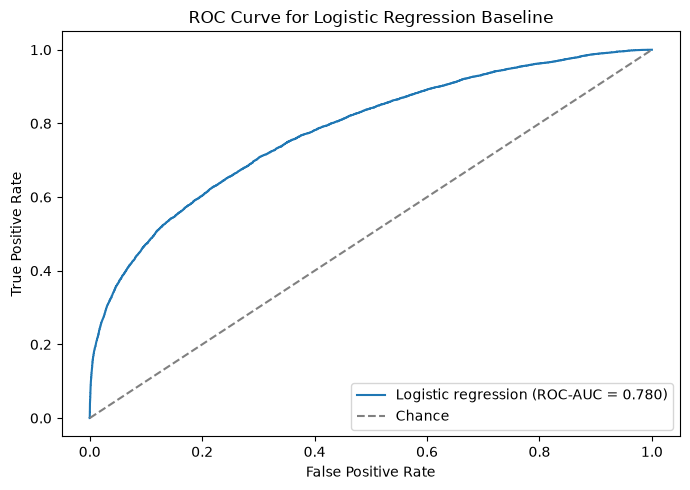

In [ ]:
#plot roc curve to assess discrimination across all classification thresholds
fpr, tpr, _ = roc_curve(y_test, logistic_test_probability)
roc_auc = roc_auc_score(y_test, logistic_test_probability)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic regression (ROC-AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression Baseline")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(logistic_output_path / "t3_2_logistic_roc_curve.png", dpi=300)
plt.show()

**Precision-recall curve**

The precision-recall curve is especially useful because the positive readmission class is less frequent than the non-readmission class.

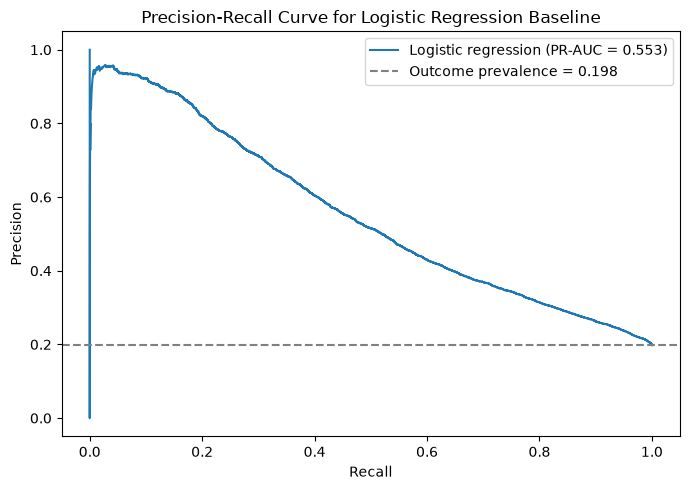

In [ ]:
#plot precision-recall curve, which is informative for an imbalanced readmission outcome
precision, recall, _ = precision_recall_curve(y_test, logistic_test_probability)
pr_auc = average_precision_score(y_test, logistic_test_probability)
base_rate = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Logistic regression (PR-AUC = {pr_auc:.3f})")
plt.axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Logistic Regression Baseline")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Calibration curve**

Calibration describes whether predicted probabilities align with observed readmission rates.

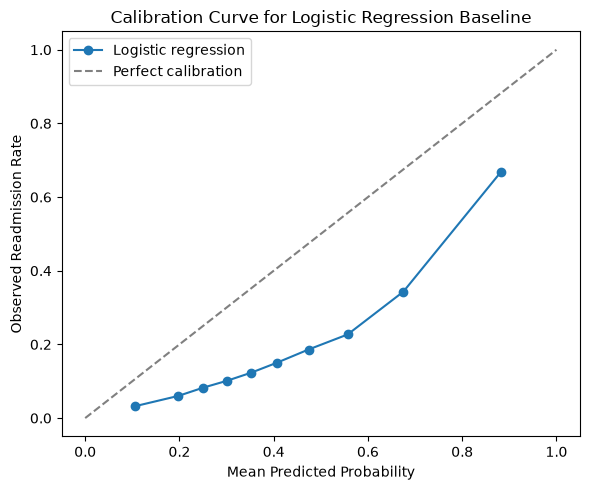

   mean_predicted_probability  observed_readmission_rate
0                      0.1064                     0.0324
1                      0.1977                     0.0602
2                      0.2506                     0.0827
3                      0.3004                     0.1011
4                      0.3522                     0.1232
5                      0.4068                     0.1503
6                      0.4739                     0.1861
7                      0.5570                     0.2271
8                      0.6752                     0.3432
9                      0.8828                     0.6693


In [ ]:
#assess calibration by comparing predicted probabilities with observed readmission rates; quantile bins keep each calibration bin similarly sized
prob_true, prob_pred = calibration_curve(y_test, logistic_test_probability, n_bins=10, strategy="quantile")
calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred,
    "observed_readmission_rate": prob_true})
calibration_df.to_csv(logistic_output_path / "t3_2_logistic_calibration_table.csv", index=False)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve for Logistic Regression Baseline")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(logistic_output_path / "t3_2_logistic_calibration_curve.png", dpi=300)
plt.show()

print(calibration_df.round(4))

**Logistic regression coefficient summary**

Coefficients provide an interpretable baseline view of which processed predictors are associated with higher or lower predicted readmission risk. Because the model uses one-hot encoded and standardised features, coefficients should be interpreted as model-specific associations rather than causal effects.

In [ ]:
#summarise logistic regression coefficients as an interpretable baseline importance table
coef_df = pd.DataFrame({"processed_feature_name": feature_names, "coefficient": logistic_model.coef_[0]})
coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()
coef_df["direction"] = np.where(coef_df["coefficient"] >= 0, "Higher predicted risk", "Lower predicted risk")
coef_df = coef_df.sort_values("absolute_coefficient", ascending=False)
coef_df.to_csv(logistic_output_path / "t3_2_logistic_regression_coefficients.csv", index=False)

print("Top 25 logistic regression coefficients by absolute magnitude:")
print(coef_df.head(25))

Top 25 logistic regression coefficients by absolute magnitude:
                             processed_feature_name  coefficient  \
854        num__late_order_intensity_score_last_12h    -1.853042   
916  cat__discharge_location_Unknown / not modelled    -1.312614   
915                 cat__discharge_location_Unknown     1.063051   
332            num__num_unique_poe_order_categories     0.865488   
923                               cat__race_UNKNOWN    -0.816727   
331                  num__num_unique_order_subtypes    -0.779955   
922                      cat__race_UNABLE TO OBTAIN    -0.587717   
136                  num__potassium_lab_value_range     0.584161   
101                    num__potassium_lab_max_value    -0.510934   
920                     cat__marital_status_Unknown    -0.469228   
342  num__had_followup_or_outpatient_referral_order     0.453064   
754      num__late_orders_but_followup_present_flag    -0.426222   
116                    num__potassium_lab_min_value  

**Tuned logistic regression**

The baseline logistic regression used a fixed regularisation strength. This experiment tunes the regularisation parameter `C` using 3-fold cross-validation on the training set only, with average precision used as the optimisation metric because the readmission outcome is imbalanced.

In [15]:
#train tuned logistic regression using the current selected wp3 matrix
#when screening is enabled, reselect c on the active matrix instead of carrying over a stale value.
logistic_C_grid = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]

if run_hyperparameter_screening:
    print("Training tuned logistic regression with cross-validated C search...")
    print("C grid:", logistic_C_grid)
    tuned_logistic_model = LogisticRegressionCV(Cs=logistic_C_grid, penalty="l2", solver="lbfgs",
        class_weight="balanced", scoring="average_precision", cv=3, max_iter=2000,
        random_state=42, refit=True)
else:
    best_tuned_logistic_C = 0.01
    print("Training tuned logistic regression with selected C...")
    print("Selected C:", best_tuned_logistic_C)
    tuned_logistic_model = LogisticRegression(penalty="l2", C=best_tuned_logistic_C,
        solver="lbfgs", class_weight="balanced", max_iter=2000, random_state=42)

tuned_training_start = time.perf_counter()
#fit the model on the current training data
tuned_logistic_model.fit(X_train, y_train)
tuned_logistic_training_time_seconds = time.perf_counter() - tuned_training_start
print("Tuned logistic regression training complete.")

if hasattr(tuned_logistic_model, "C_"):
    selected_tuned_logistic_C = float(np.ravel(tuned_logistic_model.C_)[0])
else:
    selected_tuned_logistic_C = float(tuned_logistic_model.C)
    tuned_logistic_model.C_ = np.array([selected_tuned_logistic_C])

print("Selected C:", selected_tuned_logistic_C)

tuned_train_prediction_start = time.perf_counter()
#score admissions as predicted readmission probabilities
tuned_logistic_train_probability = tuned_logistic_model.predict_proba(X_train)[:, 1]
tuned_logistic_train_inference_time_seconds = time.perf_counter() - tuned_train_prediction_start

tuned_test_prediction_start = time.perf_counter()
tuned_logistic_test_probability = tuned_logistic_model.predict_proba(X_test)[:, 1]
tuned_logistic_test_inference_time_seconds = time.perf_counter() - tuned_test_prediction_start

print("Training ROC-AUC:", round(roc_auc_score(y_train, tuned_logistic_train_probability), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, tuned_logistic_test_probability), 4))
print("Training PR-AUC:", round(average_precision_score(y_train, tuned_logistic_train_probability), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, tuned_logistic_test_probability), 4))
print("Training time in seconds:", round(tuned_logistic_training_time_seconds, 2))
print("Test inference time in seconds:", round(tuned_logistic_test_inference_time_seconds, 4))
print("Test inference time per admission in ms:", round((tuned_logistic_test_inference_time_seconds / len(y_test)) * 1000, 6))

Training tuned logistic regression with cross-validated C search...
C grid: [0.003, 0.01, 0.03, 0.1, 0.3, 1.0]
Tuned logistic regression training complete.
Selected C: 0.01
Training ROC-AUC: 0.7904
Test ROC-AUC: 0.7799
Training PR-AUC: 0.5674
Test PR-AUC: 0.5528
Training time in seconds: 211.69
Test inference time in seconds: 0.0397
Test inference time per admission in ms: 0.000842


**Cross-validation tuning results**

The cross-validation table shows how each tested regularisation strength performed during tuning. Higher average precision indicates better performance for the minority readmission class.

In [ ]:
#summarise tuned logistic regression regularisation choice
#if logisticregressioncv is used, save fold-level cv scores; otherwise record the manually selected c and fitted-model metrics.
tuning_rows = []

if hasattr(tuned_logistic_model, "scores_") and hasattr(tuned_logistic_model, "Cs_"):
    cv_scores = tuned_logistic_model.scores_[1]
    #loop through each item in this feature block
    for c_value, fold_scores in zip(tuned_logistic_model.Cs_, cv_scores.T):
        tuning_rows.append({"C": c_value, "mean_cv_average_precision": fold_scores.mean(),
            "std_cv_average_precision": fold_scores.std(), "fold_1_average_precision": fold_scores[0],
            "fold_2_average_precision": fold_scores[1], "fold_3_average_precision": fold_scores[2],
            "selection_source": "cross_validation"})
else:
    selected_c = float(tuned_logistic_model.C_[0]) if hasattr(tuned_logistic_model, "C_") else float(tuned_logistic_model.C)
    tuning_rows.append({"C": selected_c,
        "mean_cv_average_precision": np.nan,
        "std_cv_average_precision": np.nan,
        "fold_1_average_precision": np.nan,
        "fold_2_average_precision": np.nan,
        "fold_3_average_precision": np.nan,
        "selection_source": "manual_selected_previous_screening",
        "training_roc_auc": roc_auc_score(y_train, tuned_logistic_train_probability),
        "test_roc_auc": roc_auc_score(y_test, tuned_logistic_test_probability),
        "training_pr_auc_average_precision": average_precision_score(y_train, tuned_logistic_train_probability),
        "test_pr_auc_average_precision": average_precision_score(y_test, tuned_logistic_test_probability),
        "test_brier_score": brier_score_loss(y_test, tuned_logistic_test_probability)})

tuned_logistic_tuning_df = pd.DataFrame(tuning_rows)

#logisticregressioncv rows contain fold-level cv metrics for each c, while manually selected
#logisticregression rows contain fitted train/test metrics. sort only by columns that exist in the active table.
sort_columns = [column for column in ["mean_cv_average_precision", "test_pr_auc_average_precision"]
    if column in tuned_logistic_tuning_df.columns]
if sort_columns:
    tuned_logistic_tuning_df = tuned_logistic_tuning_df.sort_values(
        sort_columns, ascending=[False] * len(sort_columns), na_position="last")

selected_tuned_logistic_summary_df = pd.DataFrame([{"selected_C": float(tuned_logistic_model.C_[0]),
    "training_roc_auc": roc_auc_score(y_train, tuned_logistic_train_probability),
    "test_roc_auc": roc_auc_score(y_test, tuned_logistic_test_probability),
    "training_pr_auc_average_precision": average_precision_score(y_train, tuned_logistic_train_probability),
    "test_pr_auc_average_precision": average_precision_score(y_test, tuned_logistic_test_probability),
    "test_brier_score": brier_score_loss(y_test, tuned_logistic_test_probability)}])

#save this table or artefact for later review
tuned_logistic_tuning_df.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_cv_results.csv", index=False)
selected_tuned_logistic_summary_df.to_csv(
    tuned_logistic_output_path / "t3_2_tuned_logistic_selected_c_summary.csv", index=False)

print("Tuned logistic regression regularisation summary:")
print(tuned_logistic_tuning_df.round(4))
print()
print("Selected tuned logistic fitted-model summary:")
print(selected_tuned_logistic_summary_df.round(4))

Tuned logistic regression regularisation summary:
       C  mean_cv_average_precision  std_cv_average_precision  \
1  0.010                     0.5570                    0.0060   
2  0.030                     0.5568                    0.0062   
0  0.003                     0.5567                    0.0059   
4  0.300                     0.5567                    0.0063   
5  1.000                     0.5567                    0.0063   
3  0.100                     0.5567                    0.0064   

   fold_1_average_precision  fold_2_average_precision  \
1                    0.5507                    0.5652   
2                    0.5506                    0.5653   
0                    0.5503                    0.5646   
4                    0.5505                    0.5654   
5                    0.5505                    0.5654   
3                    0.5505                    0.5654   

   fold_3_average_precision  selection_source  
1                    0.5551  cross_validation 

**Tuned logistic regression threshold selection**

As with the original logistic regression model, threshold selection is performed using training-set predictions only.

In [ ]:
#select tuned logistic regression thresholds using training predictions only
tuned_threshold_table, tuned_best_f1_threshold, tuned_best_youden_threshold = find_best_threshold(
    y_train, tuned_logistic_train_probability)
tuned_balanced_pr_threshold = float(tuned_threshold_table.sort_values(
    ["precision_recall_gap", "f1_score"], ascending=[True, False]).iloc[0]["threshold"])
tuned_threshold_table.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_threshold_search_training.csv", index=False)

print("Best tuned logistic threshold by F1:", round(tuned_best_f1_threshold, 2))
print("Best tuned logistic threshold by Youden index:", round(tuned_best_youden_threshold, 2))
print("Balanced tuned logistic precision-recall threshold:", round(tuned_balanced_pr_threshold, 2))
print("\nTop tuned threshold rows by F1:")
print(tuned_threshold_table.sort_values("f1_score", ascending=False).head(10))

Best tuned logistic threshold by F1: 0.57
Best tuned logistic threshold by Youden index: 0.49
Balanced tuned logistic precision-recall threshold: 0.61

Top tuned threshold rows by F1:
    threshold  precision  recall_sensitivity  precision_recall_gap  f1_score  \
56       0.57   0.477917            0.567523              0.089606  0.518880   
55       0.56   0.468456            0.579957              0.111501  0.518277   
57       0.58   0.486404            0.554405              0.068001  0.518183   
58       0.59   0.495891            0.542496              0.046605  0.518147   
59       0.60   0.505220            0.530482              0.025262  0.517543   
54       0.55   0.458781            0.593260              0.134478  0.517426   
60       0.61   0.515272            0.517548              0.002276  0.516407   
53       0.54   0.449289            0.606273              0.156984  0.516107   
61       0.62   0.525919            0.505692              0.020227  0.515607   
52       0.53   

**Tuned logistic regression test-set performance**

The tuned logistic regression model is evaluated on the same held-out patient-level test set as the baseline logistic regression model.

In [ ]:
#evaluate tuned logistic regression on test set
tuned_default_metrics = evaluate_binary_predictions("Tuned logistic regression", y_test, tuned_logistic_test_probability, threshold=0.5)
tuned_f1_metrics = evaluate_binary_predictions("Tuned logistic regression", y_test, tuned_logistic_test_probability, threshold=tuned_best_f1_threshold)
tuned_youden_metrics = evaluate_binary_predictions("Tuned logistic regression", y_test, tuned_logistic_test_probability, threshold=tuned_best_youden_threshold)
tuned_balanced_pr_metrics = evaluate_binary_predictions("Tuned logistic regression balanced precision-recall threshold", y_test, tuned_logistic_test_probability, threshold=tuned_balanced_pr_threshold)

tuned_timing_kwargs = {"training_time_seconds": tuned_logistic_training_time_seconds,
    "train_inference_time_seconds": tuned_logistic_train_inference_time_seconds,
    "test_inference_time_seconds": tuned_logistic_test_inference_time_seconds,
    "number_of_test_admissions": len(y_test)}

tuned_performance_rows = [add_timing_metrics(tuned_default_metrics, **tuned_timing_kwargs),
    add_timing_metrics(tuned_f1_metrics, **tuned_timing_kwargs),
    add_timing_metrics(tuned_youden_metrics, **tuned_timing_kwargs),
    add_timing_metrics(tuned_balanced_pr_metrics, **tuned_timing_kwargs)]

tuned_performance_df = pd.DataFrame(tuned_performance_rows).round(4)
tuned_performance_df.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_regression_performance.csv", index=False)

#combine reference, baseline logistic, and tuned logistic rows for comparison
logistic_comparison_df = pd.concat([performance_df, tuned_performance_df], ignore_index=True)
logistic_comparison_df.to_csv(wp3_2_output_path / "t3_2_logistic_model_comparison.csv", index=False)

print("Tuned logistic regression performance:")
print(tuned_performance_df)
print("\nCombined WP3.2 logistic model comparison:")
print(logistic_comparison_df)

Tuned logistic regression performance:
                                               model  threshold  accuracy  \
0                          Tuned logistic regression       0.50    0.7416   
1                          Tuned logistic regression       0.57    0.7878   
2                          Tuned logistic regression       0.49    0.7345   
3  Tuned logistic regression balanced precision-r...       0.61    0.8064   

   balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  \
0             0.7027     0.4028              0.6385       0.7669    0.4940   
1             0.6991     0.4686              0.5524       0.8457    0.5070   
2             0.7036     0.3958              0.6525       0.7547    0.4927   
3             0.6911     0.5102              0.5006       0.8817    0.5054   

   roc_auc  pr_auc_average_precision  brier_score  true_negatives  \
0   0.7799                    0.5528       0.1802           29030   
1   0.7799                    0.5528       0.1

**Save tuned logistic regression predictions and model**

The tuned model is saved separately from the original logistic regression baseline so both versions can be compared in WP3.6.

In [ ]:
#save tuned model predictions and fitted model object
tuned_logistic_predictions = save_prediction_file(tuned_logistic_output_path,
    "t3_2_tuned_logistic_regression_test_predictions.csv", test_ids,
    tuned_logistic_test_probability, tuned_best_youden_threshold)

joblib.dump(tuned_logistic_model, tuned_logistic_output_path / "t3_2_tuned_logistic_regression_model.joblib")

print("Saved tuned logistic regression model and predictions to:")
print(tuned_logistic_output_path)
print("\nPrediction preview:")
print(tuned_logistic_predictions.head())

Saved tuned logistic regression model and predictions to:
/scratch/DissProject/outputs/WP3_2/tuned_logistic_regression

Prediction preview:
   subject_id   hadm_id  readmitted_30d  days_to_next  next_is_psych  \
0    10000117  22927623               0         672.0              1   
1    10000117  27988844               0           NaN              0   
2    10002221  21008195               0         984.0              1   
3    10002221  20195471               0         377.0              1   
4    10002221  21729093               1           3.0              1   

   readmitted_30d_psych  readmitted_60d_psych  readmitted_90d_psych  \
0                     0                     0                     0   
1                     0                     0                     0   
2                     0                     0                     0   
3                     0                     0                     0   
4                     1                     1                     1   



**Tuned logistic regression confusion matrix**

Confusion matrices are saved for the default and selected tuned logistic regression thresholds.

In [ ]:
#summarise confusion matrix counts for tuned logistic regression thresholds
tuned_confusion_rows = []
for model_name, y_probability, threshold in [
    ("Tuned logistic regression default threshold", tuned_logistic_test_probability, 0.5),
    ("Tuned logistic regression selected threshold", tuned_logistic_test_probability, tuned_best_youden_threshold),
    ("Tuned logistic regression balanced precision-recall threshold", tuned_logistic_test_probability, tuned_balanced_pr_threshold)]:
    tn, fp, fn, tp = confusion_matrix(y_test, (y_probability >= threshold).astype(int)).ravel()
    tuned_confusion_rows.append({"model": model_name, "threshold": threshold, "true_negatives": tn,
        "false_positives": fp, "false_negatives": fn, "true_positives": tp})

tuned_confusion_df = pd.DataFrame(tuned_confusion_rows)
tuned_confusion_df.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_confusion_matrices.csv", index=False)
print(tuned_confusion_df)

                                               model  threshold  \
0        Tuned logistic regression default threshold       0.50   
1       Tuned logistic regression selected threshold       0.49   
2  Tuned logistic regression balanced precision-r...       0.61   

   true_negatives  false_positives  false_negatives  true_positives  
0           29030             8822             3369            5950  
1           28568             9284             3238            6081  
2           33374             4478             4654            4665  


**Tuned logistic regression ROC curve**

The tuned model ROC curve is saved separately from the original logistic regression baseline.

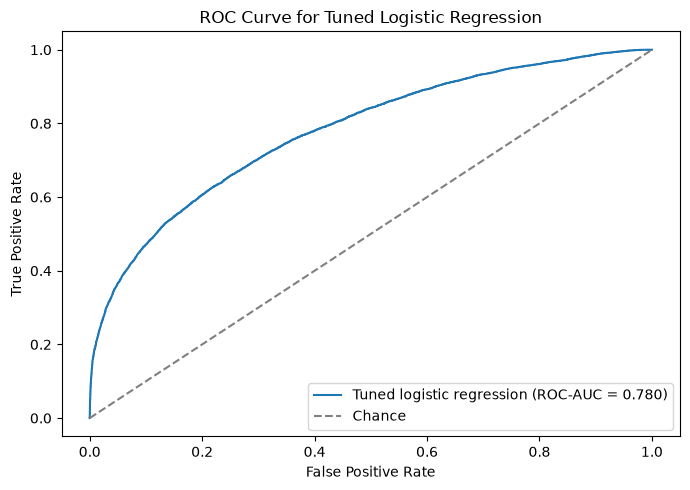

In [21]:
#plot tuned logistic regression roc curve
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_logistic_test_probability)
tuned_roc_auc = roc_auc_score(y_test, tuned_logistic_test_probability)

plt.figure(figsize=(7, 5))
plt.plot(tuned_fpr, tuned_tpr, label=f"Tuned logistic regression (ROC-AUC = {tuned_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(tuned_logistic_output_path / "t3_2_tuned_logistic_roc_curve.png", dpi=300)
plt.show()

**Tuned logistic regression precision-recall curve**

The precision-recall curve is retained because average precision is the tuning metric and is informative for the minority readmission class.

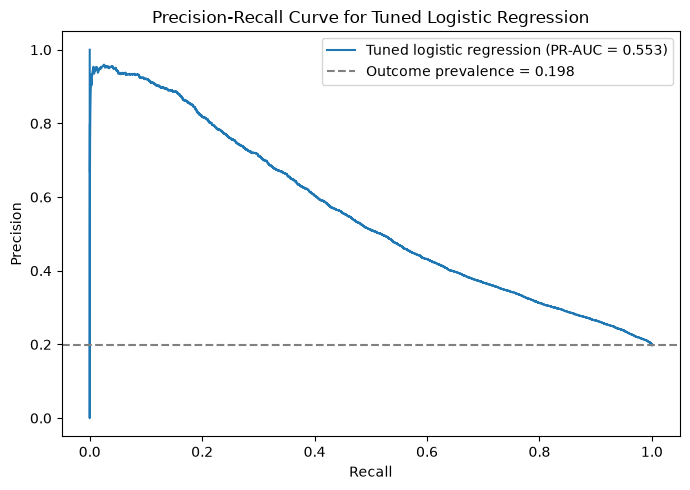

In [ ]:
#plot tuned logistic regression precision-recall curve
tuned_precision, tuned_recall, _ = precision_recall_curve(y_test, tuned_logistic_test_probability)
tuned_pr_auc = average_precision_score(y_test, tuned_logistic_test_probability)
base_rate = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(tuned_recall, tuned_precision, label=f"Tuned logistic regression (PR-AUC = {tuned_pr_auc:.3f})")
plt.axhline(base_rate, linestyle="--", color="grey", label=f"Outcome prevalence = {base_rate:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Logistic Regression")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(tuned_logistic_output_path / "t3_2_tuned_logistic_precision_recall_curve.png", dpi=300)
plt.show()

**Tuned logistic regression calibration curve**

Calibration is evaluated but not directly optimised here. Probability calibration can be revisited during final model comparison if required.

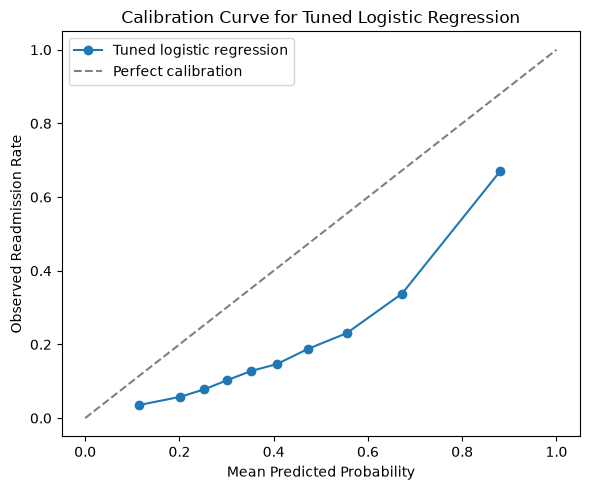

   mean_predicted_probability  observed_readmission_rate
0                      0.1150                     0.0356
1                      0.2015                     0.0577
2                      0.2527                     0.0780
3                      0.3015                     0.1030
4                      0.3527                     0.1280
5                      0.4066                     0.1465
6                      0.4731                     0.1880
7                      0.5548                     0.2304
8                      0.6724                     0.3379
9                      0.8806                     0.6703


In [ ]:
#evaluate calibration for the tuned logistic regression model
prob_true_tuned, prob_pred_tuned = calibration_curve(y_test, tuned_logistic_test_probability, n_bins=10, strategy="quantile")
tuned_calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred_tuned,
    "observed_readmission_rate": prob_true_tuned})
tuned_calibration_df.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_calibration_table.csv", index=False)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred_tuned, prob_true_tuned, marker="o", label="Tuned logistic regression")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Readmission Rate")
plt.title("Calibration Curve for Tuned Logistic Regression")
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig(tuned_logistic_output_path / "t3_2_tuned_logistic_calibration_curve.png", dpi=300)
plt.show()

print(tuned_calibration_df.round(4))

**Tuned logistic regression coefficient summary**

The tuned coefficient table allows the tuned logistic model to be interpreted alongside the original logistic regression baseline.

In [ ]:
#summarise tuned logistic regression coefficients
tuned_coef_df = pd.DataFrame({"processed_feature_name": feature_names,
    "coefficient": tuned_logistic_model.coef_[0]})
tuned_coef_df["absolute_coefficient"] = tuned_coef_df["coefficient"].abs()
tuned_coef_df["direction"] = np.where(tuned_coef_df["coefficient"] >= 0, "Higher predicted risk", "Lower predicted risk")
tuned_coef_df = tuned_coef_df.sort_values("absolute_coefficient", ascending=False)
tuned_coef_df.to_csv(tuned_logistic_output_path / "t3_2_tuned_logistic_regression_coefficients.csv", index=False)

print("Top 25 tuned logistic regression coefficients by absolute magnitude:")
print(tuned_coef_df.head(25))

Top 25 tuned logistic regression coefficients by absolute magnitude:
                                processed_feature_name  coefficient  \
916     cat__discharge_location_Unknown / not modelled    -0.939010   
915                    cat__discharge_location_Unknown     0.709792   
923                                  cat__race_UNKNOWN    -0.634711   
920                        cat__marital_status_Unknown    -0.468307   
342     num__had_followup_or_outpatient_referral_order     0.265860   
922                         cat__race_UNABLE TO OBTAIN    -0.261072   
754         num__late_orders_but_followup_present_flag    -0.250487   
854           num__late_order_intensity_score_last_12h    -0.229662   
955  cat__discharge_location_grouped_Unknown / not ...    -0.229218   
939                            cat__last_service_TRAUM    -0.227185   
953              cat__discharge_location_grouped_Other     0.218704   
937                             cat__last_service_OMED     0.209340   
928     

**Tuned logistic regression output workbook**

All tuned logistic regression tables are combined into a single workbook with separate sheets for easier review.

In [ ]:
#save tuned logistic regression tables into a single excel workbook
tuned_logistic_workbook = tuned_logistic_output_path / "t3_2_tuned_logistic_regression_tables.xlsx"
with pd.ExcelWriter(tuned_logistic_workbook) as writer:
    tuned_performance_df.to_excel(writer, sheet_name="performance", index=False)
    logistic_comparison_df.to_excel(writer, sheet_name="model_comparison", index=False)
    tuned_confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
    tuned_threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
    tuned_logistic_tuning_df.to_excel(writer, sheet_name="cv_tuning_results", index=False)
    tuned_calibration_df.to_excel(writer, sheet_name="calibration", index=False)
    tuned_coef_df.to_excel(writer, sheet_name="coefficients", index=False)

print("Saved tuned logistic regression workbook to:")
print(tuned_logistic_workbook)

Saved tuned logistic regression workbook to:
/scratch/DissProject/outputs/WP3_2/tuned_logistic_regression/t3_2_tuned_logistic_regression_tables.xlsx


**Final T3.2 output summary**

This final check confirms the files created for the logistic regression baseline.

In [ ]:
#list all files generated by this notebook; save model-specific tables into excel workbooks with separate sheets
logistic_workbook = logistic_output_path / "t3_2_logistic_regression_tables.xlsx"
with pd.ExcelWriter(logistic_workbook) as writer:
    performance_df.to_excel(writer, sheet_name="performance", index=False)
    confusion_df.to_excel(writer, sheet_name="confusion_matrices", index=False)
    threshold_table.to_excel(writer, sheet_name="threshold_search", index=False)
    calibration_df.to_excel(writer, sheet_name="calibration", index=False)
    coef_df.to_excel(writer, sheet_name="coefficients", index=False)

reference_baseline_workbook = reference_baseline_output_path / "t3_2_reference_baseline_tables.xlsx"
reference_baseline_prediction_note_df = pd.DataFrame([{"table": "test_predictions",
    "saved_as": "CSV only",
    "file_name": "t3_2_reference_baseline_test_predictions.csv",
    "reason": "Prediction-level tables are kept out of Excel workbooks to avoid slow ZIP/xlsx writes."}])
with pd.ExcelWriter(reference_baseline_workbook, engine="xlsxwriter") as writer:
    pd.DataFrame([reference_baseline_metrics]).to_excel(writer, sheet_name="performance", index=False)
    reference_baseline_prediction_note_df.to_excel(writer, sheet_name="prediction_file", index=False)

created_files = sorted(wp3_2_output_path.glob("**/t3_2_*"))
summary_df = pd.DataFrame({"output_folder": [path.parent.name for path in created_files],
    "output_file": [path.name for path in created_files],
    "file_size_mb": [round(path.stat().st_size / (1024 ** 2), 3) for path in created_files]})
summary_df.to_csv(wp3_2_output_path / "t3_2_output_file_summary.csv", index=False)

print("T3.2 output files:")
print(summary_df)
print("\nT3.2 complete. Outputs saved to:")
print(wp3_2_output_path)

T3.2 output files:
                           output_folder  \
0   calibrated_tuned_logistic_regression   
1   calibrated_tuned_logistic_regression   
2   calibrated_tuned_logistic_regression   
3   calibrated_tuned_logistic_regression   
4                    logistic_regression   
5                    logistic_regression   
6                    logistic_regression   
7                    logistic_regression   
8                    logistic_regression   
9                    logistic_regression   
10                   logistic_regression   
11                   logistic_regression   
12                   logistic_regression   
13                   logistic_regression   
14                    reference_baseline   
15                    reference_baseline   
16                    reference_baseline   
17                                 WP3_2   
18                                 WP3_2   
19             tuned_logistic_regression   
20             tuned_logistic_regression   
21           

In [ ]:
#load packages and shared helpers for this notebook
from sklearn.calibration import CalibratedClassifierCV

calibrated_logistic_output_path = wp3_2_output_path / "calibrated_tuned_logistic_regression"
calibrated_logistic_output_path.mkdir(exist_ok=True)

calibrated_base_model = LogisticRegression(penalty="l2",
    C=float(tuned_logistic_model.C_[0]), solver="lbfgs", 
    class_weight="balanced", max_iter=2000, random_state=42)

calibrated_tuned_logistic_model = CalibratedClassifierCV(
    estimator=calibrated_base_model, method="sigmoid", cv=3, n_jobs=1)

print("Training calibrated tuned logistic regression...")
calibrated_training_start = time.perf_counter()
calibrated_tuned_logistic_model.fit(X_train, y_train)
calibrated_training_time_seconds = time.perf_counter() - calibrated_training_start
calibrated_train_probability = calibrated_tuned_logistic_model.predict_proba(X_train)[:, 1]
calibrated_test_probability = calibrated_tuned_logistic_model.predict_proba(X_test)[:, 1]

print("Training ROC-AUC:", round(roc_auc_score(y_train, calibrated_train_probability), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, calibrated_test_probability), 4))
print("Training PR-AUC:", round(average_precision_score(y_train, calibrated_train_probability), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, calibrated_test_probability), 4))
print("Test Brier score:", round(brier_score_loss(y_test, calibrated_test_probability), 4))

Training calibrated tuned logistic regression...
Training ROC-AUC: 0.7901
Test ROC-AUC: 0.7797
Training PR-AUC: 0.5672
Test PR-AUC: 0.5528
Test Brier score: 0.1235


In [ ]:
#save calibrated tuned logistic regression sensitivity outputs
calibrated_logistic_output_path = wp3_2_output_path / "calibrated_tuned_logistic_regression"
calibrated_logistic_output_path.mkdir(exist_ok=True)

calibrated_test_prediction_start = time.perf_counter()
#score admissions as predicted readmission probabilities
calibrated_test_probability = calibrated_tuned_logistic_model.predict_proba(X_test)[:, 1]
calibrated_test_inference_time_seconds = time.perf_counter() - calibrated_test_prediction_start

calibrated_train_prediction_start = time.perf_counter()
calibrated_train_probability = calibrated_tuned_logistic_model.predict_proba(X_train)[:, 1]
calibrated_train_inference_time_seconds = time.perf_counter() - calibrated_train_prediction_start

calibrated_timing_kwargs = {"training_time_seconds": calibrated_training_time_seconds,
    "train_inference_time_seconds": calibrated_train_inference_time_seconds,
    "test_inference_time_seconds": calibrated_test_inference_time_seconds,
    "number_of_test_admissions": len(y_test),}

calibrated_default_metrics = evaluate_binary_predictions(
    "Calibrated tuned logistic regression", y_test,
    calibrated_test_probability, threshold=0.5)

calibrated_performance_df = pd.DataFrame([
    add_timing_metrics(calibrated_default_metrics, **calibrated_timing_kwargs)]).round(4)

calibrated_performance_df.to_csv(
    calibrated_logistic_output_path / "t3_2_calibrated_tuned_logistic_regression_performance.csv",index=False)

calibrated_predictions_df = test_ids.copy()
calibrated_predictions_df["readmitted_30d"] = y_test.values
calibrated_predictions_df["predicted_probability"] = calibrated_test_probability
calibrated_predictions_df["predicted_class"] = (
    calibrated_predictions_df["predicted_probability"] >= 0.5).astype(int)

calibrated_predictions_df.to_csv(
    calibrated_logistic_output_path / "t3_2_calibrated_tuned_logistic_regression_test_predictions.csv",index=False)

prob_true_calibrated, prob_pred_calibrated = calibration_curve(
    y_test, calibrated_test_probability, n_bins=10, strategy="quantile")

calibrated_calibration_df = pd.DataFrame({"mean_predicted_probability": prob_pred_calibrated,
    "observed_readmission_rate": prob_true_calibrated,})

calibrated_calibration_df.to_csv(
    calibrated_logistic_output_path / "t3_2_calibrated_tuned_logistic_calibration_table.csv", index=False)

#save this table or artefact for later review
joblib.dump(calibrated_tuned_logistic_model,
    calibrated_logistic_output_path / "t3_2_calibrated_tuned_logistic_regression_model.joblib")

#refresh wp3.2 file summary
wp3_2_files = []
#loop through each item in this feature block
for file_path in sorted(wp3_2_output_path.rglob("*")):
    if file_path.is_file():
        wp3_2_files.append({"output_folder": file_path.parent.name, "output_file": file_path.name,
            "file_size_mb": round(file_path.stat().st_size / (1024 * 1024), 3),})

wp3_2_output_summary_df = pd.DataFrame(wp3_2_files)
wp3_2_output_summary_df.to_csv(wp3_2_output_path / "t3_2_output_file_summary.csv", index=False)

print("Calibrated tuned logistic regression performance:")
print(calibrated_performance_df)

print("\nCurrent WP3.2 output file summary:")
print(wp3_2_output_summary_df)

Calibrated tuned logistic regression performance:
                                  model  threshold  accuracy  \
0  Calibrated tuned logistic regression        0.5    0.8371   

   balanced_accuracy  precision  recall_sensitivity  specificity  f1_score  \
0             0.6261     0.7313              0.2774       0.9749    0.4022   

   roc_auc  pr_auc_average_precision  brier_score  true_negatives  \
0   0.7797                    0.5528       0.1235           36902   

   false_positives  false_negatives  true_positives  training_time_seconds  \
0              950             6734            2585                 73.129   

   train_inference_time_seconds  test_inference_time_seconds  \
0                          0.47                       0.1202   

   test_inference_time_per_admission_ms  
0                                0.0025  

Current WP3.2 output file summary:
                           output_folder  \
0   calibrated_tuned_logistic_regression   
1   calibrated_tuned_logistic_r

**Consolidated CSV Table Workbook**

This cell keeps the individual CSV files and also creates one Excel workbook where each CSV table is available as a separate sheet. The workbook is for easier review and sharing; the CSV files remain the primary machine-readable outputs.


In [ ]:
#compile csv tables into one workbook while preserving the original csv files
possible_output_roots = []

#loop through each item in this feature block
for output_name in ['wp3_2_output_path']:
    if output_name in globals():
        output_root = globals()[output_name]
        if isinstance(output_root, Path) and output_root.exists() and output_root not in possible_output_roots:
            possible_output_roots.append(output_root)

if not possible_output_roots:
    print("no wp3 output roots were available for workbook compilation")
else:
    primary_output_root = possible_output_roots[0]
    workbook_path = primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook.xlsx"
    csv_paths = []
    #loop through each item in this feature block
    for output_root in possible_output_roots:
        csv_paths.extend(sorted(path for path in output_root.rglob("*.csv") if path.is_file()))
    csv_paths = sorted(dict.fromkeys(csv_paths))

    #make sheet name
    def make_sheet_name(csv_path, used_names):
        relative_name = csv_path.relative_to(primary_output_root.parent).with_suffix("").as_posix()
        relative_name = re.sub(r"[^0-9a-zA-Z]+", "_", relative_name).strip("_").lower()
        parts = [part for part in relative_name.split("_") if part not in ["outputs", primary_output_root.name.lower(), "csv", "tables"]]
        base_name = "_".join(parts[-4:]) if parts else csv_path.stem.lower()
        base_name = base_name[:31] or "table"
        sheet_name = base_name
        counter = 1
        while sheet_name in used_names:
            suffix = f"_{counter}"
            sheet_name = base_name[:31 - len(suffix)] + suffix
            counter += 1
        used_names.add(sheet_name)
        return sheet_name

    workbook_index_rows = []
    used_sheet_names = set()
    max_excel_rows = 200000
    with pd.ExcelWriter(workbook_path) as writer:
        #loop through each item in this feature block
        for csv_path in csv_paths:
            try:
                table_df = pd.read_csv(csv_path)
            except Exception as error:
                workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": "", "rows": np.nan,
                    "columns": np.nan, "rows_written": 0, "note": f"read_failed: {error}"})
                continue
            sheet_name = make_sheet_name(csv_path, used_sheet_names)
            rows_written = min(len(table_df), max_excel_rows)
            #save this table or artefact for later review
            table_df.head(max_excel_rows).to_excel(writer, sheet_name=sheet_name, index=False)
            workbook_index_rows.append({"csv_path": str(csv_path), "sheet_name": sheet_name, "rows": len(table_df),
                "columns": table_df.shape[1], "rows_written": rows_written,
                "note": "truncated_for_excel" if len(table_df) > max_excel_rows else "complete"})
        workbook_index_df = pd.DataFrame(workbook_index_rows)
        #save this table or artefact for later review
        workbook_index_df.to_excel(writer, sheet_name="workbook_index", index=False)
    #save this table or artefact for later review
    workbook_index_df.to_csv(primary_output_root / f"{primary_output_root.name.lower()}_csv_table_workbook_index.csv", index=False)
    print("csv table workbook saved to:")
    print(workbook_path)
    display(workbook_index_df)

csv table workbook saved to:
/scratch/DissProject/outputs/WP3_2/wp3_2_csv_table_workbook.xlsx


,csv_path,sheet_name,rows,columns,rows_written,note
0,/scratch/DissProject/outputs/WP3_2/calibrated_...,tuned_logistic_calibration_tabl,10,2,10,complete
1,/scratch/DissProject/outputs/WP3_2/calibrated_...,tuned_logistic_regression_perfo,1,19,1,complete
2,/scratch/DissProject/outputs/WP3_2/calibrated_...,logistic_regression_test_predic,47171,15,47171,complete
3,/scratch/DissProject/outputs/WP3_2/logistic_re...,2_logistic_calibration_table,10,2,10,complete
4,/scratch/DissProject/outputs/WP3_2/logistic_re...,2_logistic_confusion_matrices,4,6,4,complete
5,/scratch/DissProject/outputs/WP3_2/logistic_re...,2_logistic_regression_coefficie,973,4,973,complete
6,/scratch/DissProject/outputs/WP3_2/logistic_re...,2_logistic_regression_performan,5,19,5,complete
7,/scratch/DissProject/outputs/WP3_2/logistic_re...,logistic_regression_test_pred_1,47171,15,47171,complete
8,/scratch/DissProject/outputs/WP3_2/logistic_re...,logistic_threshold_search_train,99,8,99,complete
9,/scratch/DissProject/outputs/WP3_2/reference_b...,reference_baseline_test_predict,47171,15,47171,complete
